<a href="https://colab.research.google.com/github/KosTeS1/test-external/blob/new-branch/Homework_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задание 1**

---

С помощью python смоделировать игру против лотерейного автомата типа «777».

Игрок платит 1 руб., после чего выпадает случайное целое число, равномерно распределенное от 0 до 999.
При некоторых значениях числа игрок получает выигрыш:

(* – любая цифра)
Выгодна ли игра игроку?
Сколько в среднем приобретает или теряет игрок за одну игру?

ЛОТЕРЕЙНЫЙ БАНДИТ'777'

РЕЗУЛЬТАТЫ (100000 игр):
Средний результат за игру: 1.703 руб.
ВЫВОД: Игра ВЫГОДНА для игрока!
Игрок в среднем ВЫИГРЫВАЕТ 1.703 руб. за игру


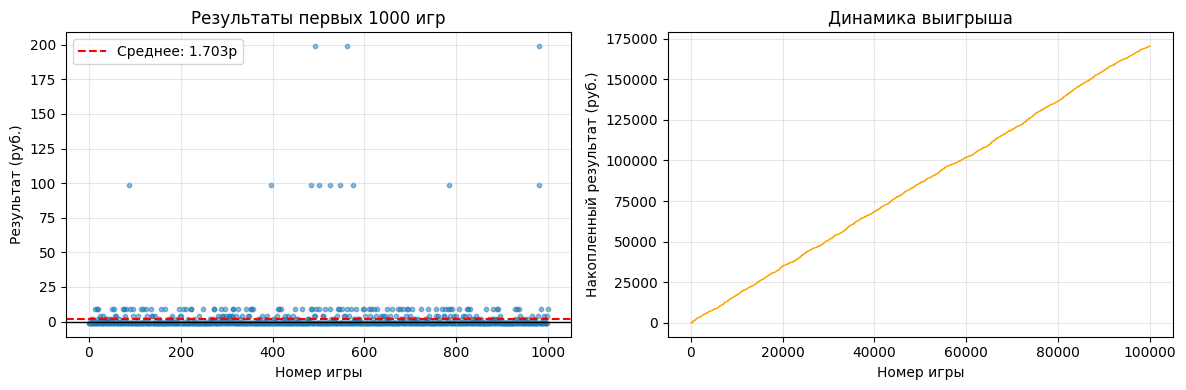

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры игры
COST_PER_GAME = 1  # Стоимость одной игры 1 рубль
NUM_SIMULATIONS = 100000  # Количество игр

def check_win(number):
    """Проверяем выигрышные комбинации"""
    num_str = str(number).zfill(3)

    if number == 777:
        return 200
    if num_str[0] == num_str[1] == num_str[2]:
        return 100
    if num_str[1] == num_str[2]:
        return 10
    if num_str[0] == num_str[1]:
        return 5
    if num_str[0] == num_str[2]:
        return 3
    return 0

print("ЛОТЕРЕЙНЫЙ БАНДИТ'777'\n")

# Проводим симуляцию
results = []
total_profit = 0

for i in range(NUM_SIMULATIONS):
    num = np.random.randint(0, 1000)
    win = check_win(num)
    net_result = win - COST_PER_GAME
    results.append(net_result)
    total_profit += net_result

# Статистика
avg_profit = total_profit / NUM_SIMULATIONS

print(f"РЕЗУЛЬТАТЫ ({NUM_SIMULATIONS} игр):")
print(f"Средний результат за игру: {avg_profit:.3f} руб.")

if avg_profit > 0:
    print("ВЫВОД: Игра ВЫГОДНА для игрока!")
    print(f"Игрок в среднем ВЫИГРЫВАЕТ {avg_profit:.3f} руб. за игру")
else:
    print("ВЫВОД: Игра НЕВЫГОДНА для игрока!")
    print(f"Игрок в среднем ПРОИГРЫВАЕТ {abs(avg_profit):.3f} руб. за игру")

# Визуализация (первые 1000 игр для наглядности)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(range(1000), results[:1000], alpha=0.5, s=10)
plt.axhline(y=avg_profit, color='red', linestyle='--', label=f'Среднее: {avg_profit:.3f}р')
plt.axhline(y=0, color='black', linewidth=1)
plt.xlabel('Номер игры')
plt.ylabel('Результат (руб.)')
plt.title('Результаты первых 1000 игр')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(np.cumsum(results), 'orange', linewidth=1)
plt.xlabel('Номер игры')
plt.ylabel('Накопленный результат (руб.)')
plt.title('Динамика выигрыша')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Задание 2 (дополнительное задание повышенной сложности)**

---

Теоретически рассчитать средний выигрыш (проигрыш) и сравнить с результатами моделирования
**Решение:**
1. Взяли каждое число от 0 до 999 и превратили в строку из 3 цифр
2. Проверил от большего выигрыша к меньшему, чтобы каждое число считалось только один раз
3. Посчитали вероятност - иожидание дискретной случайной величины
4. Вычли стоимость игры 1 руб.
5. Сравнили с моделированием


In [22]:
print("\n" + "="*50)
print("ЗАДАНИЕ 2: ТЕОРЕТИЧЕСКИЙ РАСЧЕТ и СРАВНЕНИЕ")
print("="*50)

# Проверяем все числа от 0 до 999 и считаем каждое число только один раз
win_stats = {200: 0, 100: 0, 10: 0, 5: 0, 3: 0, 0: 0}

for number in range(1000):
    num_str = str(number).zfill(3)

    # Проверяем в порядке убывания выигрыша
    if number == 777:
        win_stats[200] += 1
    elif num_str[0] == num_str[1] == num_str[2]:
        win_stats[100] += 1
    elif num_str[1] == num_str[2]:
        win_stats[10] += 1
    elif num_str[0] == num_str[1]:
        win_stats[5] += 1
    elif num_str[0] == num_str[2]:
        win_stats[3] += 1
    else:
        win_stats[0] += 1

# Теоретический расчет
theoretical_avg_win = sum(win * (win_stats[win]/1000) for win in [200, 100, 10, 5, 3])
theoretical_profit = theoretical_avg_win - 1

print("ТОЧНЫЕ ВЕРОЯТНОСТИ:")
for win_amount in [200, 100, 10, 5, 3]:
    count = win_stats[win_amount]
    print(f"Выигрыш {win_amount} руб.: {count}/1000 = {count/1000:.3f}")
print(f"Проигрыш: {win_stats[0]}/1000 = {win_stats[0]/1000:.3f}")

print(f"\nТеоретический средний выигрыш: {theoretical_avg_win:.3f} руб.")
print(f"За вычетом стоимости игры:    {theoretical_profit:.3f} руб.")

print(f"\nСРАВНЕНИЕ:")
print(f"Теория:   {theoretical_profit:.3f} руб.")
print(f"Практика: {avg_profit:.3f} руб.")

if abs(theoretical_profit - avg_profit) < 0.02:
    print("Теория и практика совпадают!")
else:
    print("Есть расхождения")


ЗАДАНИЕ 2: ТЕОРЕТИЧЕСКИЙ РАСЧЕТ и СРАВНЕНИЕ
ТОЧНЫЕ ВЕРОЯТНОСТИ:
Выигрыш 200 руб.: 1/1000 = 0.001
Выигрыш 100 руб.: 9/1000 = 0.009
Выигрыш 10 руб.: 90/1000 = 0.090
Выигрыш 5 руб.: 90/1000 = 0.090
Выигрыш 3 руб.: 90/1000 = 0.090
Проигрыш: 720/1000 = 0.720

Теоретический средний выигрыш: 2.720 руб.
За вычетом стоимости игры:    1.720 руб.

СРАВНЕНИЕ:
Теория:   1.720 руб.
Практика: 1.703 руб.
Теория и практика совпадают!
